In [29]:
# !pip install uproot
# !pip install awkward
# !pip install matplotlib

In [30]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import vector
import matplotlib

In [31]:
file = uproot.open('sample_root_files/output_570.root') # Opening file

In [32]:
file.keys()                                             # Printing all trees

['Events;1', 'LuminosityBlocks;1', 'Runs;1', 'untagged;1']

In [33]:
events_tree = file['Events']                            # Assigning events tree to events_tree
# print(events_tree.keys())

In [7]:
eft_coeff = events_tree['EFTfitCoefficients'].array()   # Using EFTfitCoefficients branch and converting it into array

In [150]:
sum_of_coeff = []                                       # Empty list

for coefficient in np.arange(0,len(eft_coeff[0])):
  b = 0                                                 # We will store the total sum of each coefficient in the following step:
  b = np.sum(eft_coeff[:,coefficient])
  sum_of_coeff.append(b)                                # Store the value in the empty list

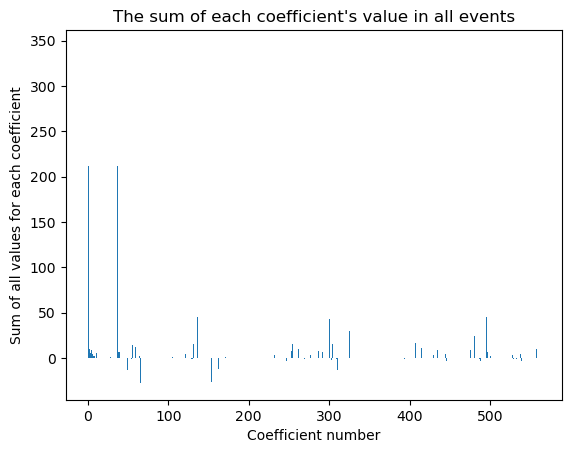

In [8]:
plt.bar(np.arange(1,562),np.array(sum_of_coeff))        # We use plt.bar and not plt.hist since we already have the x and y values!
plt.xlabel('Coefficient number')
plt.ylabel('Sum of all values for each coefficient')
plt.title(r"The sum of each coefficient's value in all events")
plt.show()

In [9]:
# We could also do a (not really informative) histogram of all the values of the coefficients:

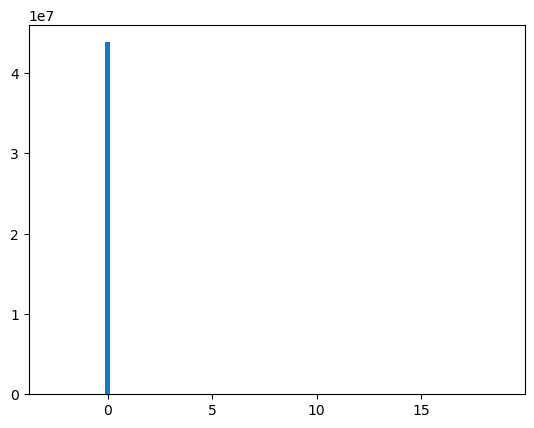

In [10]:
plt.hist(ak.flatten(eft_coeff), bins = 100)
plt.show()

In [11]:
# This is the same graph that appears if we do root!

In [151]:
# let's make a 3D graph with the x-axis as the event number, the y-axis as the number of the coefficient, and
# the color as the value of the coefficient

x_axis = np.arange(1,len(eft_coeff)+1)                  # Setting event numbers
y_axis = np.arange(1, len(eft_coeff[0])+1)              # Setting coefficient numbers

b = False
a = 0
asdf = []
while b == False:                                       # This while loop repeats the y_axis so we can assign 561 coefficients to 
    for i in y_axis:                                    # a single event (equivalent of assigning 561 y-values to a single x-value).
        asdf.append(i)
    a += 1
    if a == len(x_axis):
        b = True

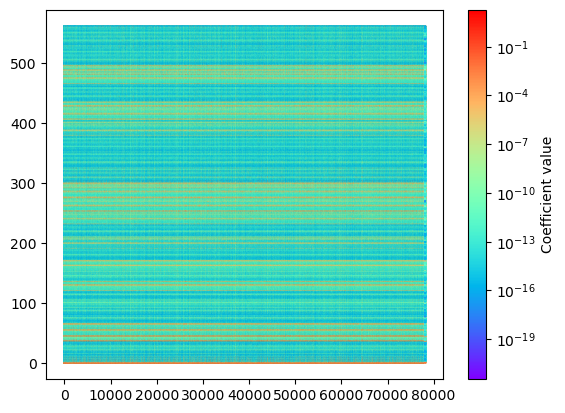

CPU times: user 5min 57s, sys: 2.26 s, total: 6min
Wall time: 6min 1s


In [39]:
%%time
# Graphing the scatter plot

plt.scatter(np.repeat(x_axis, len(y_axis)), np.array(asdf), c = np.array(ak.flatten(eft_coeff)), cmap='rainbow', 
            s = 0.5, norm=matplotlib.colors.LogNorm())
# plt.yscale('log')
# plt.xscale('log')
plt.colorbar(label='Coefficient value')
plt.show()

In [12]:
wc_names = events_tree['WCnames'].array()   # Using EFTfitCoefficients branch and converting it into array

In [13]:
wc_names

<Array [[1666282808, ..., 1668572209], ..., [...]] type='78146 * var * int32'>

In [16]:
def decode_wcs(arr):
    wcs = []
    for i,x in enumerate(arr):
        h = hex(x)[2:]  # Chop off '0x' piece
        str_fragment = bytes.fromhex(h).decode('utf-8')
        if str_fragment.startswith("-"):
            # Handle the case where a WC is >4 characters long
            wcs[-1] = wcs[-1] + str_fragment[1:]
        else:
            wcs.append(str_fragment)
    return wcs

In [19]:
decode_wcs(wc_names[0])

['cQu8',
 'ctu8',
 'cQu1',
 'ctd8',
 'cQlMi',
 'cpQ3',
 'ctlTi',
 'ctG',
 'ctZ',
 'ctW',
 'ctli',
 'ctb8',
 'cbW',
 'cQl3i',
 'cQq13',
 'cptb',
 'ctp',
 'ctei',
 'cpQM',
 'ctlSi',
 'cQq83',
 'cQq81',
 'ctq1',
 'ctu1',
 'cQei',
 'cQb8',
 'cpt',
 'ctq8',
 'cQd1',
 'cQq11',
 'cQd8',
 'ctd1']

In [20]:
names_json = ["SM","cQu8","ctu8","cQu1","ctd8","cQlMi","cpQ3","ctlTi","ctG","ctZ","ctW","ctli","ctb8","cbW","cQl3i","cQq13",
              "cptb","ctp","ctei","cpQM","ctlSi", "cQq83","cQq81","ctq1","ctu1","cQei","cQb8","cpt","ctq8","cQd1","cQq11",
              "cQd8","ctd1"]

In [23]:
names_json[1:] == decode_wcs(wc_names[0])

True

In [ ]:
events_tree